# Homework

OpenTelemetry (OTel) is the industry standard for code instrumentation. It describes what a program does as traces, spans and attributes, and pluggable exporters decide where that data goes: console, database, or platforms like Langfuse and Logfire, all built on top of OTel. The instrumented code never changes, only the destination.

- **Trace**: the full recording of one request, from the moment it enters the system to the moment the answer leaves. Here the system is the RAG, so one call to rag() is one request and produces one trace. Ask another question, get a new trace.
- **Span**: one step inside that journey. Each span has a name, a start and end time, and attributes, and spans nest into a tree: a span opened inside another becomes its child. Our trace has three spans, rag as the root with search and llm as its children. In an agent the same tree grows to many spans, one per model call and tool call.
- **Attributes**: key-value pairs attached to a span, anything worth recording about that step, like the number of tokens or the cost of a call.

The lifecycle ties it together. Instrumentation is the with tracer.start_as_current_span blocks in the code: they declare what to measure. When such a block completes, the span is finished and the SDK hands it to a span processor, which forwards it to an exporter, the component that decides the destination. The code that creates spans never knows where they end up. That separation is the whole point: in module 5, saving to Postgres meant calling save_conversation inside the app code, and changing storage would mean editing the app; with OTel the RAG code stays untouched and the same spans get redirected from console to SQLite just by swapping the exporter.

In [1]:
import sys
sys.path.append("/workspace/llm-zoomcamp-2026/05-monitoring/homework/code")
from starter import rag

answer = rag.rag("How does the agentic loop keep calling the model until it stops?")
print(answer)


The loop keeps calling the model by checking whether the model returned any `function_call` items.

- It sends the current `messages` history to the model.
- If the response includes a function call, your code runs the tool, appends the tool output to `messages`, and sets `has_function_calls = True`.
- After that turn, if `has_function_calls` is `False`, the loop breaks.
- So the loop stops when the model returns a response with no function calls — meaning it has given its final answer.

In short: **keep looping while the model asks for tools; stop when it doesn’t.**


## Q1. First trace

Wrap the `rag()` method so each call produces a span. The simplest way
is to create a `RAGTraced` subclass of `RAGBase` that wraps `rag()`,
`search()`, and `llm()` each in their own span.

Run this query:

> How does the agentic loop keep calling the model until it stops?

The console exporter prints every finished span as a dictionary.
Count the spans in the console output - each one is a separate
`ReadableSpan` entry. How many spans does the trace produce?

- 1
- **3**
- 5
- 7

Three OpenTelemetry concepts carry the whole homework:

- Trace: the end to end story of one request. Here, one RAG call is one trace.
- Span: one operation inside the trace, with a name, start and end times, and attributes (key value pairs like token counts). Spans nest into a tree: a span opened inside another becomes its child.
- Exporter: the destination of finished spans. Console for now, SQLite from Q4 on.

The setup below builds the chain that connects them, line by line:

- TracerProvider() is the central configuration object of the SDK. It owns the processors and decides how spans are built.
- SimpleSpanProcessor(ConsoleSpanExporter()) wires a processor that hands every finished span to the console exporter, synchronously and one at a time. Simple means immediate, good for development.
- trace.set_tracer_provider(provider) registers the provider globally, so any get_tracer call anywhere in the code is backed by it.
- trace.get_tracer("llm-zoomcamp") returns the tracer used to create spans. The string is only a label identifying which part of the code produced them.


In [2]:
from opentelemetry import trace
from opentelemetry.sdk.trace import TracerProvider
from opentelemetry.sdk.trace.export import ConsoleSpanExporter, SimpleSpanProcessor

provider = TracerProvider()
provider.add_span_processor(SimpleSpanProcessor(ConsoleSpanExporter()))
trace.set_tracer_provider(provider)

tracer = trace.get_tracer("llm-zoomcamp")


RAGTraced is the same subclass trick as RAGWithMetrics from lesson 04, with spans instead of a manual clock. Each overridden method wraps super() in start_as_current_span, and because rag calls search and llm internally, their spans are born inside the rag span and become its children in the trace tree. The RAG logic itself stays untouched, inherited from RAGBase, and the instance reuses the index and client that starter already built.

In [3]:
from rag_helper import RAGBase
from starter import index, client


class RAGTraced(RAGBase):

    def rag(self, query):
        with tracer.start_as_current_span("rag"):
            return super().rag(query)

    def search(self, query, num_results=5):
        with tracer.start_as_current_span("search"):
            return super().search(query, num_results=num_results)

    def llm(self, prompt):
        with tracer.start_as_current_span("llm"):
            return super().llm(prompt)


rag_traced = RAGTraced(index=index, llm_client=client)


In [4]:
answer = rag_traced.rag("How does the agentic loop keep calling the model until it stops?")
print(answer)


{
    "name": "search",
    "context": {
        "trace_id": "0xc5e40117e018d6f57129df7641c9c2fa",
        "span_id": "0xd5899757e1649f11",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0xf425420a532d2c5a",
    "start_time": "2026-07-15T19:38:53.129503Z",
    "end_time": "2026-07-15T19:38:53.134855Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {},
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.43.0",
            "service.instance.id": "a31937be-c10e-4b7f-b41c-afd30b5bf417",
            "service.name": "unknown_service"
        },
        "schema_url": ""
    }
}
{
    "name": "llm",
    "context": {
        "trace_id": "0xc5e40117e018d6f57129df7641c9c2fa",
        "span_id": "0x910e8ec475bf8804",
        "trace_state": "[]"
    },
    "kind": "SpanKind

```
rag        (53.129431 -> 54.910587)  ~1.78s
├── search (53.129503 -> 53.134855)  ~5ms
└── llm    (53.136106 -> 54.909760)  ~1.77s
```

## Q2. Capturing metrics as span attributes

Spans are not just timing markers - you can attach any information you
want to them with `set_attribute`. We already use spans to record how
long each step takes. Now we'll add the metrics we care about: tokens
and cost.

Read the token usage from the LLM response (the `llm()` method in the
starter already returns the raw response object) and set them as
attributes on the `llm` span:

```python
span.set_attribute("input_tokens", usage.input_tokens)
span.set_attribute("output_tokens", usage.output_tokens)
```

And since we know both input and output tokens, we can also compute
the cost using the code from the previous modules.

Now re-run the query. How many input tokens do we see?

- 700
- **7000 ("input_tokens": 7111)**
- 70000
- 700000

In [5]:
def calculate_cost(model, usage):
    cost = 0
    if "gpt-5.4-mini" in model:
        cost = (usage.input_tokens * 0.15 + usage.output_tokens * 0.60) / 1_000_000
    return cost


class RAGTraced(RAGBase):

    def rag(self, query):
        with tracer.start_as_current_span("rag"):
            return super().rag(query)

    def search(self, query, num_results=5):
        with tracer.start_as_current_span("search"):
            return super().search(query, num_results=num_results)

    def llm(self, prompt):
        with tracer.start_as_current_span("llm") as span:
            response = super().llm(prompt)
            usage = response.usage
            span.set_attribute("input_tokens", usage.input_tokens)
            span.set_attribute("output_tokens", usage.output_tokens)
            span.set_attribute("cost", calculate_cost(self.model, usage))
            return response


rag_traced = RAGTraced(index=index, llm_client=client)


In [6]:
answer = rag_traced.rag("How does the agentic loop keep calling the model until it stops?")


{
    "name": "search",
    "context": {
        "trace_id": "0x0d7caf72cecb14bb6493898335dd550f",
        "span_id": "0x610452a9712e16fc",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x1829ea85c100a46e",
    "start_time": "2026-07-15T20:23:40.143195Z",
    "end_time": "2026-07-15T20:23:40.155838Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {},
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.43.0",
            "service.instance.id": "a31937be-c10e-4b7f-b41c-afd30b5bf417",
            "service.name": "unknown_service"
        },
        "schema_url": ""
    }
}
{
    "name": "llm",
    "context": {
        "trace_id": "0x0d7caf72cecb14bb6493898335dd550f",
        "span_id": "0xdc7f8bd0181683f7",
        "trace_state": "[]"
    },
    "kind": "SpanKind

In [ ]:
{
    "name": "llm",
    "context": {
        "trace_id": "0x0d7caf72cecb14bb6493898335dd550f",
        "span_id": "0xdc7f8bd0181683f7",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x1829ea85c100a46e",
    "start_time": "2026-07-15T20:23:40.157837Z",
    "end_time": "2026-07-15T20:23:44.656062Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "input_tokens": 7111,
        "output_tokens": 129,
        "cost": 0.00114405
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.43.0",
            "service.instance.id": "a31937be-c10e-4b7f-b41c-afd30b5bf417",
            "service.name": "unknown_service"
        },
        "schema_url": ""
    }
}


## Q3. Span timing

Each span automatically records its duration. Look at the console output
from Q1 and find the durations for the `search` span and the `llm` span.

For a typical query, roughly how long does the LLM call take?

- Under 100ms
- 100-500ms
- **500-2000ms**
- Over 2000ms

In [7]:
%%capture
import time

query = "How does the agentic loop keep calling the model until it stops?"

durations_ms = []
for _ in range(8):
    start = time.time()
    rag_traced.rag(query)
    durations_ms.append((time.time() - start) * 1000)

{
    "name": "search",
    "context": {
        "trace_id": "0xb41125cf36da8ac2c98c21544c8b1b89",
        "span_id": "0x3e50df2be357299f",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x813594ea7bbed70e",
    "start_time": "2026-07-15T20:29:37.614121Z",
    "end_time": "2026-07-15T20:29:37.618895Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {},
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.43.0",
            "service.instance.id": "a31937be-c10e-4b7f-b41c-afd30b5bf417",
            "service.name": "unknown_service"
        },
        "schema_url": ""
    }
}
{
    "name": "llm",
    "context": {
        "trace_id": "0xb41125cf36da8ac2c98c21544c8b1b89",
        "span_id": "0xf9f781eaa459a07d",
        "trace_state": "[]"
    },
    "kind": "SpanKind

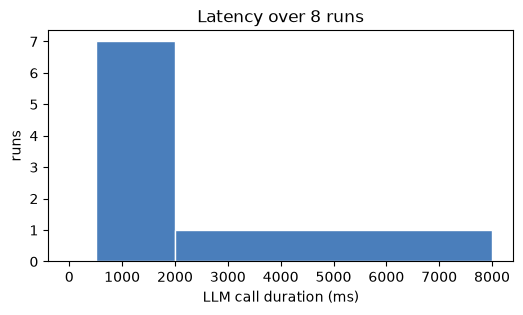

[1259, 1312, 1404, 1551, 1581, 1587, 1924, 2400]

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3))
plt.hist(durations_ms, bins=[0, 100, 500, 2000, max(8000, max(durations_ms))],
         color="#4a7ebb", edgecolor="white")
plt.xlabel("LLM call duration (ms)")
plt.ylabel("runs")
plt.title("Latency over 8 runs")
plt.show()

sorted(round(d) for d in durations_ms)


## Q4. Saving traces to SQLite

Right now the spans are printed to the terminal and then gone. We don't
save them.

We want to persist them so we can query them later.

In this homework, we'll use SQLite - it's a more lightweight option than
Postgres, so we don't need to set up any docker containers in this homework.

Our instrumentation is already done, we don't need to change anything there.
But we need to create a custom exporter. Instead of printing the spans,
it will save them to the database.

OTel calls the exporter through the same span processor we already use,
we just swap the destination.

Now we will create a custom exporter that saves each finished span to a
SQLite database. The exporter extends `SpanExporter`. It has the following methods:

- `export` method that receives a list of `ReadableSpan` objects
- `shutdown` and `force_flush` methods

Let's implement it:

```python
import sqlite3
from opentelemetry.sdk.trace.export import SpanExporter, SpanExportResult


class SQLiteSpanExporter(SpanExporter):

    def __init__(self, db_path="traces.db"):
        self.conn = sqlite3.connect(db_path)
        self.conn.execute("""
            CREATE TABLE IF NOT EXISTS spans (
                name TEXT,
                start_time INTEGER,
                end_time INTEGER,
                input_tokens INTEGER,
                output_tokens INTEGER,
                cost REAL
            )
        """)
        self.conn.commit()

    def export(self, spans):
        for span in spans:
            attrs = dict(span.attributes or {})
            self.conn.execute(
                "INSERT INTO spans VALUES (?, ?, ?, ?, ?, ?)",
                (
                    span.name,
                    span.start_time,
                    span.end_time,
                    attrs.get("input_tokens"),
                    attrs.get("output_tokens"),
                    attrs.get("cost"),
                ),
            )
        self.conn.commit()
        return SpanExportResult.SUCCESS

    def shutdown(self):
        self.conn.close()

    def force_flush(self):
        return True
```

Replace the console exporter with this new exporter:

```python
provider.add_span_processor(
    SimpleSpanProcessor(SQLiteSpanExporter("traces.db"))
)
```

Re-run the query from Q1. Which span names appear in the `spans` table?

- Only `rag`
- `rag` and `llm`
- **`rag`, `search`, and `llm`**
- `search`, `llm`, and `judge`


In [9]:
import sqlite3
from opentelemetry.sdk.trace.export import SpanExporter, SpanExportResult

DB_PATH = "/workspace/llm-zoomcamp-2026/05-monitoring/homework/data/traces.db"


class SQLiteSpanExporter(SpanExporter):

    def __init__(self, db_path="traces.db"):
        self.conn = sqlite3.connect(db_path)
        self.conn.execute("""
            CREATE TABLE IF NOT EXISTS spans (
                name TEXT,
                start_time INTEGER,
                end_time INTEGER,
                input_tokens INTEGER,
                output_tokens INTEGER,
                cost REAL
            )
        """)
        self.conn.commit()

    def export(self, spans):
        for span in spans:
            attrs = dict(span.attributes or {})
            self.conn.execute(
                "INSERT INTO spans VALUES (?, ?, ?, ?, ?, ?)",
                (
                    span.name,
                    span.start_time,
                    span.end_time,
                    attrs.get("input_tokens"),
                    attrs.get("output_tokens"),
                    attrs.get("cost"),
                ),
            )
        self.conn.commit()
        return SpanExportResult.SUCCESS

    def shutdown(self):
        self.conn.close()

    def force_flush(self):
        return True

provider.add_span_processor(
    SimpleSpanProcessor(SQLiteSpanExporter(DB_PATH))
)


In [10]:
answer = rag_traced.rag("How does the agentic loop keep calling the model until it stops?")

conn = sqlite3.connect(DB_PATH)
conn.execute("SELECT DISTINCT name FROM spans").fetchall()


{
    "name": "search",
    "context": {
        "trace_id": "0x3bfbc20a30c7e2f44498981ca6829288",
        "span_id": "0x0fbf92bec85f32f0",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x9c882be0999af0ae",
    "start_time": "2026-07-15T20:31:58.538254Z",
    "end_time": "2026-07-15T20:31:58.540497Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {},
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.43.0",
            "service.instance.id": "a31937be-c10e-4b7f-b41c-afd30b5bf417",
            "service.name": "unknown_service"
        },
        "schema_url": ""
    }
}
{
    "name": "llm",
    "context": {
        "trace_id": "0x3bfbc20a30c7e2f44498981ca6829288",
        "span_id": "0x1318932f9067c0de",
        "trace_state": "[]"
    },
    "kind": "SpanKind

[('search',), ('llm',), ('rag',)]

The exporter is the only new code: it receives finished spans and writes one row per span into SQLite, reading the token attributes when present, NULL otherwise. It plugs into the same provider as a second processor, so every span now goes to both console and database. The RAG code did not change at all, which is the entire argument of OTel: same instrumentation, swappable destinations. All three span names land in the table.


## Q5. Querying trace data

The traces are now in SQLite. Run one more query through the traced
RAG, then query the database.

The `rag` span wraps everything, so its duration includes both
`search` and `llm`. To see where time actually goes, exclude the
`rag` span and compare the children.

Using SQL (or pandas), compute the total duration for each span name
excluding `rag`. Which span type takes the most total time?

* `search`
* **`llm`**
* They're all about the same


In [11]:
import pandas as pd

answer = rag_traced.rag("How does the agentic loop keep calling the model until it stops?")

df = pd.read_sql("SELECT * FROM spans", sqlite3.connect(DB_PATH))
df["duration_ms"] = (df.end_time - df.start_time) / 1e6

df[df.name != "rag"].groupby("name").duration_ms.sum()


{
    "name": "search",
    "context": {
        "trace_id": "0x111449f0f70f171ab0984dadf7b5d631",
        "span_id": "0xd5ee4cc85ccb2408",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0xbf817e9b1aa9d489",
    "start_time": "2026-07-15T20:33:58.306437Z",
    "end_time": "2026-07-15T20:33:58.310303Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {},
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.43.0",
            "service.instance.id": "a31937be-c10e-4b7f-b41c-afd30b5bf417",
            "service.name": "unknown_service"
        },
        "schema_url": ""
    }
}
{
    "name": "llm",
    "context": {
        "trace_id": "0x111449f0f70f171ab0984dadf7b5d631",
        "span_id": "0x711f58ca561c16c6",
        "trace_state": "[]"
    },
    "kind": "SpanKind

name
llm       3645.287222
search       6.108939
Name: duration_ms, dtype: float64


## Q6. Token stability across runs

Load the SQLite data with pandas. One thing a dashboard can tell you
is how stable your system is. If the same query always produces the
same number of input tokens, the context your RAG retrieves is
consistent. If it varies a lot, something in the search may be
unstable.

Run the same query from Q1 three more times (so you have 4 RAG calls
total in the database). Then compute the input tokens for each `llm`
span.

How much do the input tokens vary across these 4 runs?

- **They're identical**
- Within 10% of each other
- Within 50% of each other
- They vary more than 50%

In [12]:
%%capture
for _ in range(2):
    rag_traced.rag("How does the agentic loop keep calling the model until it stops?")


{
    "name": "search",
    "context": {
        "trace_id": "0x38dff7bba8d08ac1f7f170c13752298f",
        "span_id": "0xc098c1251ddbbc88",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": "0x245818367bc4bdd4",
    "start_time": "2026-07-15T20:35:22.708210Z",
    "end_time": "2026-07-15T20:35:22.712350Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {},
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.43.0",
            "service.instance.id": "a31937be-c10e-4b7f-b41c-afd30b5bf417",
            "service.name": "unknown_service"
        },
        "schema_url": ""
    }
}
{
    "name": "llm",
    "context": {
        "trace_id": "0x38dff7bba8d08ac1f7f170c13752298f",
        "span_id": "0x26a00458c36b4c48",
        "trace_state": "[]"
    },
    "kind": "SpanKind

In [13]:
df = pd.read_sql("SELECT * FROM spans", sqlite3.connect(DB_PATH))
tokens = df[df.name == "llm"].input_tokens

print(tokens.tolist())
spread = (tokens.max() - tokens.min()) / tokens.min() * 100
print(f"min={tokens.min()} max={tokens.max()} variation={spread:.1f}%")


[7111.0, 7111.0, 7111.0, 7111.0]
min=7111.0 max=7111.0 variation=0.0%


The four runs of the same query produced exactly the same input token count, 7111, a 0.0% variation. What varies between runs is the output the model writes and the latency, never the input. On a dashboard, a drifting input token count for a repeated query would be the first sign that something in retrieval is broken.


# Homework: dlt

The last homework connects the pieces end to end: the module 1 FAQ agent rewritten in Pydantic AI, instrumented with Logfire, which is OpenTelemetry underneath, and the traces pulled back out with dlt into DuckDB for analysis. Conceptually nothing is new here; every span idea from the OTel homework above applies unchanged, they are just produced automatically by instrument_pydantic_ai instead of by hand.

Two manual steps happen outside the notebook, once: create a free Logfire account with a project, generate a write token and a read token, and add both to /workspace/.env as LOGFIRE_TOKEN and LOGFIRE_READ_TOKEN. The setup cell below downloads the ready made agent into homework/code_dlt and installs the three new libraries, which also go into requirements.txt for future image rebuilds.

In [16]:
%%bash
# the notebook image has curl but not wget
mkdir -p /workspace/llm-zoomcamp-2026/05-monitoring/homework/code_dlt
cd /workspace/llm-zoomcamp-2026/05-monitoring/homework/code_dlt
PREFIX=https://raw.githubusercontent.com/DataTalksClub/llm-zoomcamp/main/cohorts/2026/workshops/dlt/homework
curl -sfO $PREFIX/agent.py
curl -sfO $PREFIX/ingest.py
curl -sfO $PREFIX/main.py
pip -q install pydantic-ai logfire "dlt[duckdb]"
ls

agent.py
ingest.py
main.py



## Question 1. Instrument the agent with Logfire

Sign up for a free [Logfire](https://logfire.dev) account, create a
project, and generate a write token. Put it in `.env` as
`LOGFIRE_TOKEN`.

Instrument the agent:

```python
logfire.configure()
logfire.instrument_pydantic_ai()
```

Run the agent a few times with different questions and open your
project on Logfire to see the traces.

For the following query

> How do I run Ollama locally?

how many spans does a single agent run produce?

Each span is either the agent run itself, an LLM call, or a tool call.
The number can vary between runs because the model decides how many
times to search.

- 1
- **5**
- 15
- 30


The agent is the module 1 assistant in Pydantic AI clothes: same instructions, the search tool over the minsearch index registered with a decorator, and the agent loop built into run_sync. Instrumentation is two lines. configure() connects to the Logfire project through LOGFIRE_TOKEN, and instrument_pydantic_ai() hooks every agent run, model request and tool call, producing automatically the spans we created by hand in the OTel homework. The trace shows up in the Logfire web UI: one span for the agent run, one per LLM call, one per tool call. The model decides how many searches to make, so the span count varies between runs; the answer is the option closest to what the trace shows.

In [17]:
import sys
from dotenv import load_dotenv

load_dotenv("/workspace/.env")
sys.path.append("/workspace/llm-zoomcamp-2026/05-monitoring/homework/code_dlt")

import logfire

logfire.configure()
logfire.instrument_pydantic_ai()

from agent import faq_agent, SearchDeps
from ingest import build_index, load_faq_data

documents = load_faq_data()
index = build_index(documents)
deps = SearchDeps(index=index)

Logfire project URL: https://logfire-us.pydantic.dev/marcosbenicio/llm-zoomcamp

In [19]:
# run_sync creates its own event loop, which collides with the one Jupyter
# already runs; inside a notebook the async run with top level await is the way
result = await faq_agent.run("How do I run Ollama locally?", deps=deps)
print(result.output)

21:01:08.600 faq_agent run
21:01:08.606   chat gpt-5.4-mini
21:01:10.714   running tool: search
21:01:10.732   chat gpt-5.4-mini
21:01:11.888   running tool: search
21:01:11.898   chat gpt-5.4-mini
To run Ollama locally, the course FAQ says:

1. Install Ollama from https://ollama.com/download  
   - macOS: download and install the `.pkg`
   - Windows: download and install the `.msi`
   - Linux:
     ```bash
     curl -fsSL https://ollama.com/install.sh | sh
     ```

2. Start a model locally:
   ```bash
   ollama run llama3
   ```
   This will download the model, start it locally, and open a chat interface.

3. Test that the local server is running:
   ```bash
   curl http://localhost:11434
   ```

4. If you want to use it from Python, install the client:
   ```bash
   pip install ollama
   ```

   Example:
   ```python
   import ollama

   response = ollama.chat(
       model='llama3',
       messages=[{"role": "user", "content": your_prompt}]
   )

   print(response['message']['conte


## Question 2. Load traces into DuckDB with dlt

Generate a read token for your Logfire project and set it as
`LOGFIRE_READ_TOKEN` in `.env`.

Initialize a dlt-hub project like in the workshop. Then ask your coding
agent to pull the data from Pydantic Logfire and save it into DuckDB.

The dltHub AI workbench has a ready-made context for Logfire. Point your
agent to it: https://dlthub.com/context/source/logfire

If you don't currently use a coding agent, you can use something like OpenCode:
you should be able to complete one session with the free account.

Alternatively, you can do it in the old way (using ChatGPT or your favorite search engine).

If you don't currently use a coding agent, you can use something like OpenCode:
you should be able to complete one session with the free account. 

Alternatively, you can do it in the old way (using ChatGPT or your favorite search engine).

The logfire traces contain deeply nested JSON (span attributes with
LLM messages, tool calls, token usage, etc.). dlt automatically
normalizes this into a set of tables - one for the main records, plus
child tables for each nested level.

How many tables did dlt create? Check with:

```sql
SELECT COUNT(*) FROM information_schema.tables 
WHERE table_schema = 'agent_traces';
```

- 1
- 3
- **24**
- 100


The pipeline pulls every record of the last day from the Logfire query API and hands the rows to dlt. Three details make it work, all found the hard way. The API is a POST to /v2/query with the SQL and a mandatory min_timestamp, authenticated with the read token, and the base URL depends on the region of the project, us or eu. The attributes column usually arrives as a dict but some rows carry a JSON string or an empty string, so the resource normalizes it before yielding; the nested dicts are what dlt spreads into child tables, one main records table plus one per nested level, and a few _dlt bookkeeping tables that count too, since they live in the same schema. And the duckdb file name must differ from the dataset name, because duckdb treats the file as a catalog and a catalog named exactly like the schema makes every reference ambiguous.

In [21]:
import json
import os
from datetime import datetime, timedelta, timezone

import dlt
import requests

LOGFIRE_API = "https://logfire-us.pydantic.dev"   # logfire-eu if the project is in the EU region

# the duckdb FILE name must differ from the dataset name: duckdb treats the
# file as a catalog, and a catalog named like the schema is ambiguous
DUCKDB_PATH = "/workspace/llm-zoomcamp-2026/05-monitoring/homework/data/logfire_traces.duckdb"


@dlt.resource(name="records", write_disposition="replace")
def logfire_records():
    headers = {
        "Authorization": f"Bearer {os.environ['LOGFIRE_READ_TOKEN']}",
        "Accept": "application/json",
    }
    body = {
        "sql": "SELECT * FROM records",
        "min_timestamp": (datetime.now(timezone.utc) - timedelta(days=1)).isoformat(),
        "limit": 10_000,
    }
    resp = requests.post(f"{LOGFIRE_API}/v2/query", json=body, headers=headers)
    resp.raise_for_status()

    for row in resp.json()["data"]:
        # attributes usually arrives as a dict, but some rows carry a JSON
        # string or an empty string; normalize so dlt always sees a dict
        attrs = row.get("attributes")
        if isinstance(attrs, str):
            try:
                row["attributes"] = json.loads(attrs)
            except json.JSONDecodeError:
                row["attributes"] = None
        yield row


pipeline = dlt.pipeline(
    pipeline_name="logfire_traces",
    destination=dlt.destinations.duckdb(DUCKDB_PATH),
    dataset_name="agent_traces",
)

info = pipeline.run(logfire_records())
print(info)

2026-07-15 21:04:49,453|[WARNING]|84|129499909797696|dlt|validate.py|verify_normalized_table:113|In schema `logfire_traces`: The following columns in table 'records' did not receive any data during this load and therefore could not have their types inferred:
  - attributes__model_request_parameters__output_object
  - attributes__model_request_parameters__prompted_output_template
  - attributes__model_request_parameters__thinking
  - deployment_environment
  - exception_message
  - exception_stacktrace
  - exception_type
  - http_method
  - http_response_status_code
  - http_route
  - log_body
  - otel_status_message
  - service_version
  - url_full
  - url_path
  - url_query

Unless type hints are provided, these columns will not be materialized in the destination.
One way to provide type hints is to use the 'columns' argument in the '@dlt.resource' decorator.  For example:

@dlt.resource(columns={'attributes__model_request_parameters__output_object': {'data_type': 'text'}})

2026-07-1

Pipeline logfire_traces load step completed in 0.76 seconds
1 load package(s) were loaded to destination duckdb and into dataset agent_traces
The duckdb destination used duckdb:////workspace/llm-zoomcamp-2026/05-monitoring/homework/data/logfire_traces.duckdb location to store data
Load package 1784149488.9914455 is LOADED and contains no failed jobs


In [22]:
import duckdb

dconn = duckdb.connect(DUCKDB_PATH)
dconn.execute("""
    SELECT COUNT(*) FROM information_schema.tables
    WHERE table_schema = 'agent_traces'
""").fetchall()

[(24,)]


## Question 3. Query traces with an agent

Using a coding agent (you can also write the code by hand) find the
input token usage for the agent run from Q1.

The token counts are stored in the span attributes as
`gen_ai.usage.input_tokens`. Sum them across all LLM calls within the
trace. The number depends on how many searches the agent made, so
report the range it falls into:

- 100 - 500
- **1500 - 5000**
- 10000 - 20000
- 50000 - 100000


The token counts live in the span attributes as gen_ai.usage.input_tokens, flattened by dlt into a column of the records table during normalization, with the dots turned into underscores by the naming convention. The first query discovers the exact column name dlt produced; if it differs from the one used in the sum below, adjust it there. The second query sums input tokens per trace: only LLM call spans carry the attribute, every other span contributes NULL and drops out of the sum, so the row of the Q1 trace answers the question.

In [23]:
dconn.execute("""
    SELECT table_name, column_name FROM information_schema.columns
    WHERE table_schema = 'agent_traces' AND column_name LIKE '%input_tokens%'
""").fetchall()

[('records', 'attributes__gen_ai_usage_input_tokens'),
 ('records', 'attributes__gen_ai_aggregated_usage_cache_read_input_tokens'),
 ('records', 'attributes__gen_ai_aggregated_usage_input_tokens'),
 ('records', 'attributes__gen_ai_usage_cache_read_input_tokens')]

In [24]:
dconn.execute("""
    SELECT trace_id,
           MIN(start_timestamp) AS started,
           SUM(attributes__gen_ai_usage_input_tokens) AS input_tokens
    FROM agent_traces.records
    WHERE attributes__gen_ai_usage_input_tokens IS NOT NULL
    GROUP BY trace_id
    ORDER BY started DESC
""").df()

,trace_id,started,input_tokens
0,019f67955878eb161c86da06aa2fc427,2026-07-15 21:01:08.606785+00:00,4141.0
